<a href="https://colab.research.google.com/github/evelyndenissegonzalez-lang/Estadisticainferencial2026A/blob/main/problemario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [77]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/evelyndenissegonzalez-lang/Estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df = pd.read_csv(link_csv)
df

,Promedio_de_examenes_cortos,Promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


# **1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [78]:
x = df ['Promedio_de_examenes_cortos']
y = df['Promedio_final']

# **2.   Realice un diagrama de dispersión para estos datos.**

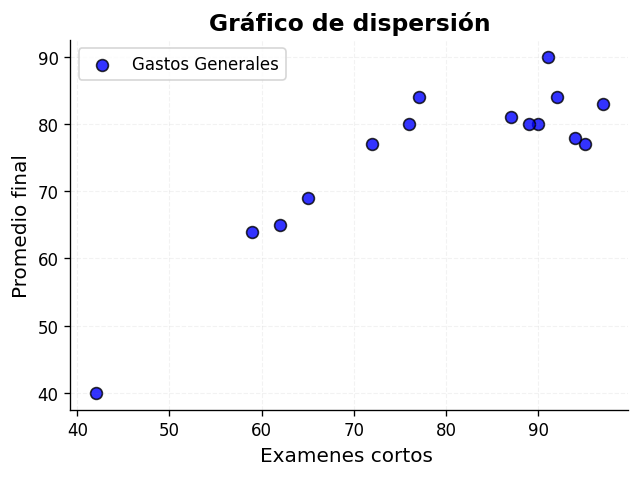

In [79]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes cortos ',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

# **3. ¿Los datos soportan la suposición de linealidad? No, ya que no muestran hasta hora un orden especifico.**

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [80]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


**Interpretación del resultado: Segun h0 si la correlacón es igual a 0 no hay correlacón, por lo tanto  como el valor de p=0 existe evidencia de correlación lineal significativa.**

In [81]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
Promedio_de_examenes_cortos,0.643180


$$
\hat{y} = 24.526822+0.643180X
$$
donde
- $\hat{y}$ es el promedio final
calculando por el modelo
- $X$ es el promedio de examenes cortos

# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [82]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



**Interpretación de resultados: significa que el 74% de la variabilidad en calificación final de los estudantes se aplica por sus calificaciones en los exámenes cortos como el prefosor suponia.**

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

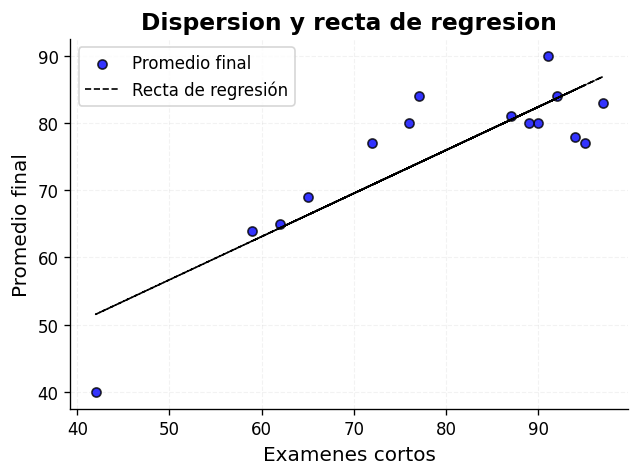

In [83]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersion y recta de regresion',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [84]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
Promedio_de_examenes_cortos,0.419219,0.867141


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.901827735700704


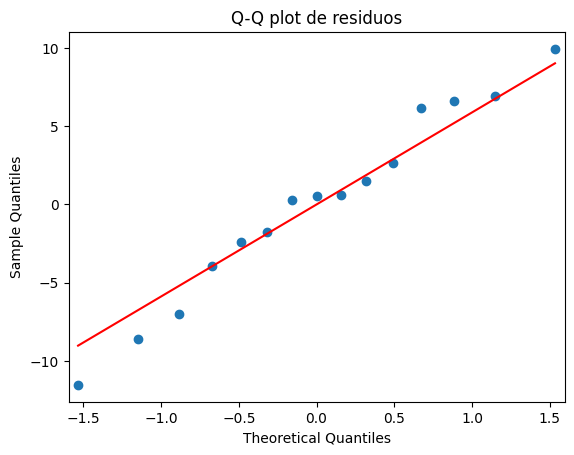

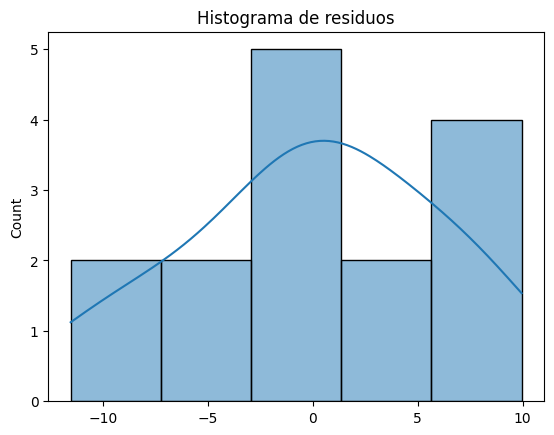

In [85]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión.**

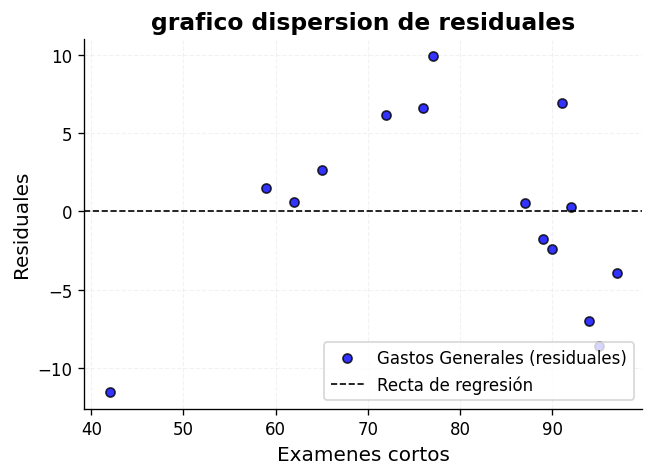

In [86]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'grafico dispersion de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes cortos',
    fontsize=12
)

plt.ylabel(
    'Residuales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Comente, ¿Parece que se verifican los supuestos? Para saber si cumplen si cumplen con los requísitos necesarios para determinar un modelo.**

**Interpretación de resultados: según el modelo, establece que si p > a 0.5 los residuos siguen una distribucón normal**

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [87]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



**Interpretación de resultados: según el modelo, si el valor p es menor que < 0.5, significa que no hay evidencia de heterocedasticidad.**

# **11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?**

In [88]:
 modelo.predict([1, 70])

array([69.54941193])

In [89]:
 modelo.predict([1, 75])

array([72.76531124])

In [90]:
 modelo.predict([1, 84])

array([78.55393001])

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [91]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Promedio_final ~ Promedio_de_examenes_cortos', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Promedio_de_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


**Interpretación: si el valor p es < 0.05, lo que significa que los examenes si funcionan y son validos para predecir la calificación final.**

### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [92]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/evelyndenissegonzalez-lang/Estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problemas_02.csv"
df = pd.read_csv(link_csv)
df

,categoria_salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


# **1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [93]:
x = df ['ausencias']
y = df['categoria_salario']

# **2.   Realice un diagrama de dispersión para estos datos.**

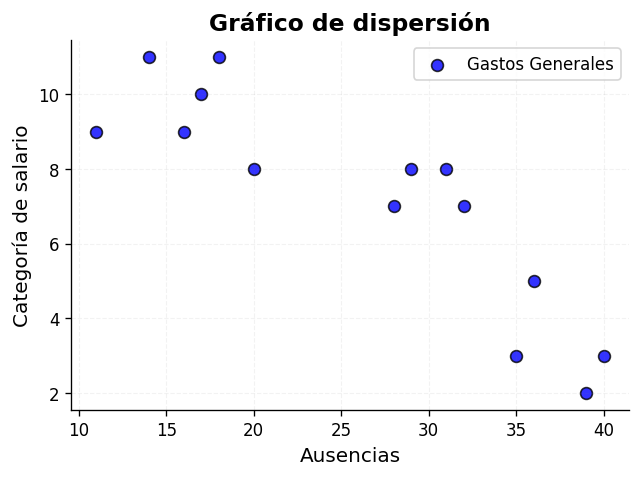

In [94]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoría de salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

# **3. ¿Los datos soportan la suposición de linealidad?Si, ya que ambos siguen un patron lineal**

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [95]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
Valor p:  0.0000


# **Interpreta el resultado:El coeficiente nos dice que a mayor salario, menos faltas, porque se relacionan entre si.**

In [96]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,14.058843
ausencias,-0.261814


$$
\hat{y} = 14.058843-0.261814x
$$
donde
- $\hat{y}$ es la categoria de salarios
- $X$ es la ausencia

# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [97]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  77.46%



**Interprete el reultado:** El porcentaje nos indica que aproximadamente el 77.46% de las faltas son popr el sueldo y las otras por otros motivos.

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

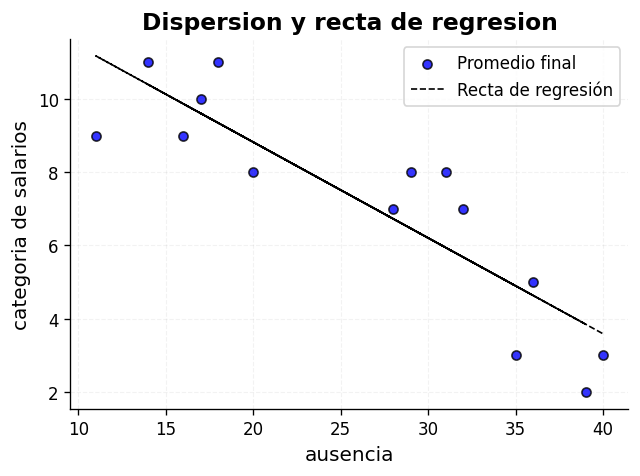

In [98]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersion y recta de regresion',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'ausencia',
    fontsize=12
)

plt.ylabel(
    'categoria de salarios',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [99]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado**

valor-p (Shapiro) = 0.4172971767713699


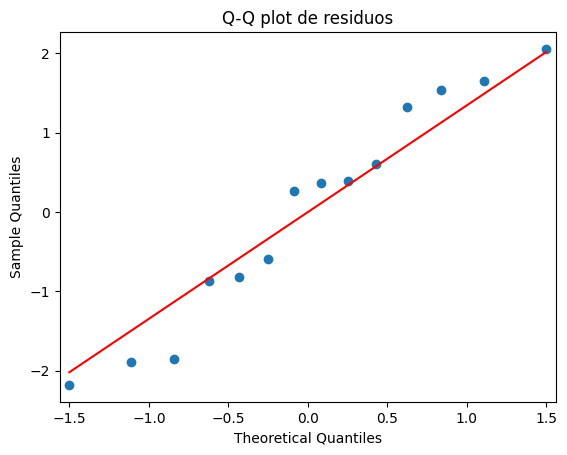

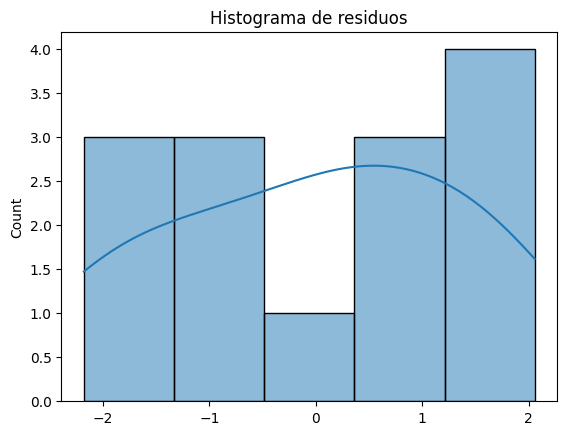

In [100]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Interpretación:** Ambas gráficas, los errores existentes en ambos casos suelen comportarse de manera normal, por lo que estan en un rango aceptable y son confiables.

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión.**

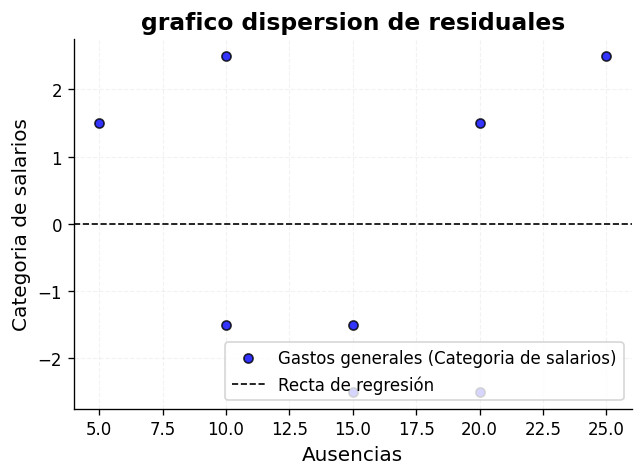

In [152]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales (Categoria de salarios)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'grafico dispersion de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoria de salarios',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

# **Comente, ¿Parece que se verifican los supuestos?**

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [102]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.8955



# **Resultados:** Ambas variables cuentan dispersión de errores similares.

# **11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [103]:
modelo.predict([1, 45])

array([2.27722772])

In [104]:
modelo.predict([1,25])

array([7.51350135])

In [105]:
modelo.predict([1, 40])

array([3.58629613])

Si se busca un sueldo ya establecido podemos suponer que es seguro y confiable, mientras que si se busca uno mas alto o mas bajo, no llegara a ser seguro.

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [106]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('categoria_salario ~ ausencias', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
ausencias,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


**Interpretación:** La prueba confirma que los datos si son dependientes, en este caso, que los sueldos si ocasionan las faltas.

### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [107]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/evelyndenissegonzalez-lang/Estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_probelma_03.csv"
df = pd.read_csv(link_csv)
df

,Gastos_generales,unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


# **1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [108]:
x = df ['unidades']
y = df['Gastos_generales']

# **2.   Realice un diagrama de dispersión para estos datos.**

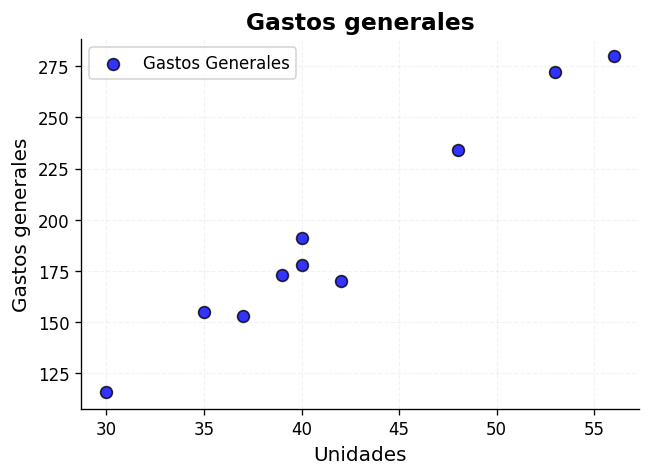

In [109]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gastos generales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

# **3. ¿Los datos soportan la suposición de linealidad?** Si, ya que tanto las unidades como los gastos generales aascienden a la misma dirección.

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [110]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
Valor p:  0.0000


**Interpretación del resultado:** Al tener un número cercano al 1, podemos concluir que los datos se relacionanentre si, a mayor gasto, mayores unidades.

In [111]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,-80.442857
unidades,6.491497


$$
\hat{y} = 13.360132+0.149011x
$$
donde
- $\hat{y}$ Los gastos generales
- $X$ son las unidades

# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [112]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.73%



# **Interpretación:** Según el codigo utilizado, dice que el 96.73% depende de la variable que se planteó en un principio, por lo que el restante se deben a razones distintas.

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

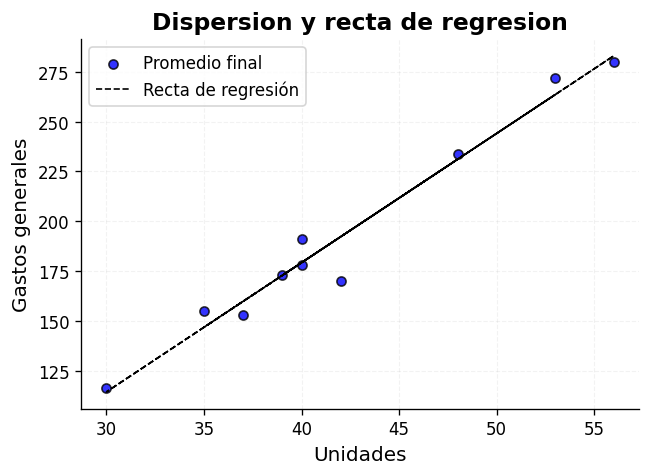

In [113]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersion y recta de regresion',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [114]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-121.986373,-38.899341
unidades,5.518450,7.464543


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.22045077017698533


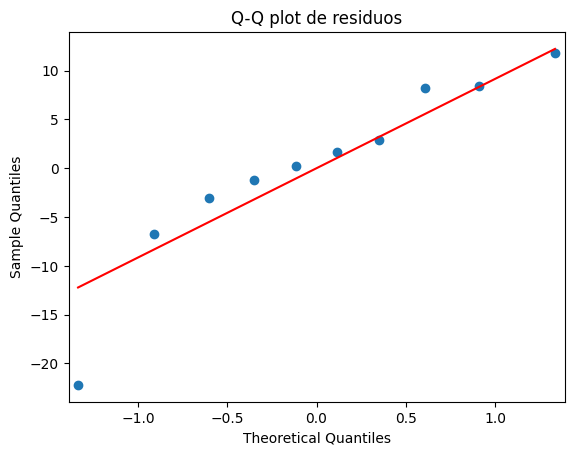

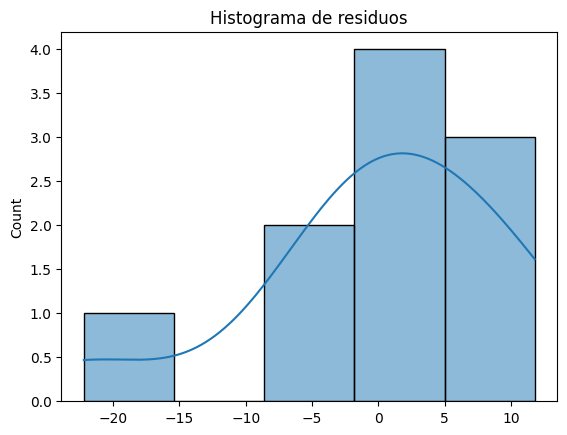

In [115]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

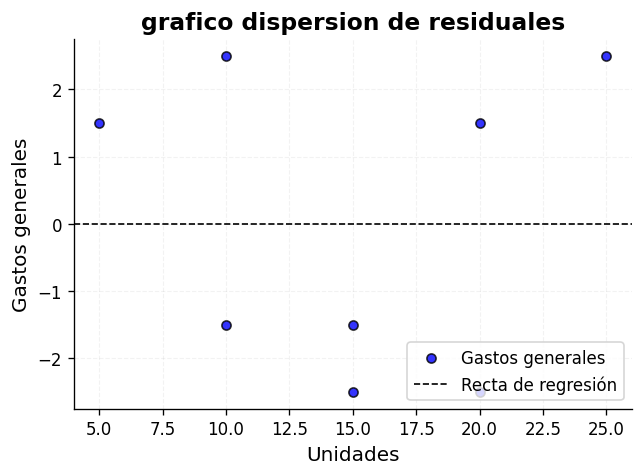

In [153]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'grafico dispersion de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

# **¿Parece que se verifican los supuestos?** Si, ya que el supuesto no sigue un orden diferente al que se adapte, por lo que las formulas anteriores funcionan.

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [117]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.9858



**Se muestra que los errores se comportan de la misma forma, aumentando equivalentemente unos con otros.**

# **11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [118]:
modelo.predict([1, 46])

array([218.16598639])

In [119]:
modelo.predict([1, 26])

array([88.33605442])

In [120]:
modelo.predict([1, 62])

array([322.02993197])

**Si tenemos en cuenta los datos que interpolamos, estamos de acuerdo con que los resultados son seguros, ya que se muestran en las graficas, asi que los datos que extrapolamos no los tenemos en cuenta en las graficas y no sabemos los resultados posibles de estos.**

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [121]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Gastos_generales ~ unidades', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)

**Gracias a esta prueba podemos cornfirmar que los gastos generales son una causa directa de las unidades, por lo que mayor producción, mayor inversión.**

**Interpretación:**

### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [122]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/evelyndenissegonzalez-lang/Estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_04.csv"
df = pd.read_csv(link_csv)
df

,Construcción_de_casas,Venta_de_linea_blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


# **1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [123]:
x = df ['Construcción_de_casas']
y = df['Venta_de_linea_blanca']

# **2.   Realice un diagrama de dispersión para estos datos.**

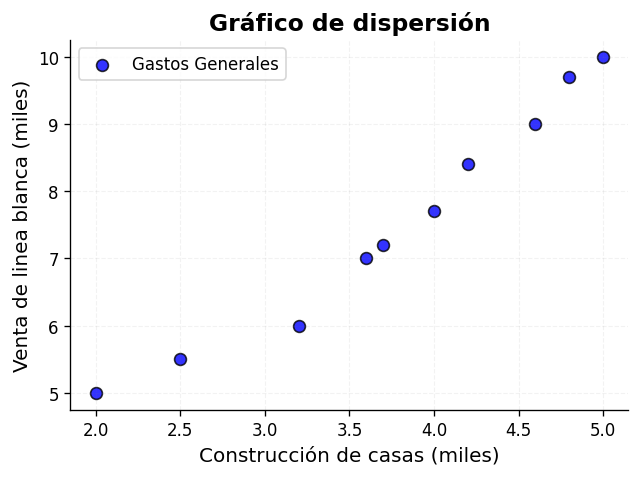

In [124]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Venta de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )


# **3. ¿Los datos soportan la suposición de linealidad?** Si, ya que ambas variables ascienden, por lo que siguen graficamente la suposición lineal.

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [125]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
Valor p:  0.0000


**Interpretación:** Ya que el valor se acerca al 1, asiq ue asumimos que ambos datos se relacionan entre si, teniendo un argumento mas a nuestra hipótesis.

In [126]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,1.016760
Construcción_de_casas,1.737564


$$
\hat{y} = 1.016760+1.737564x
$$
donde
- $\hat{y}$ es la categoria de salarios
- $X$ es la ausencia

# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [127]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.19%



**Interpretación:** guiandonos por el porcentaje, podemos decir que en su mayoria las ventas de las lienasblancas dependen de cuantas casas hay en contrucción.

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

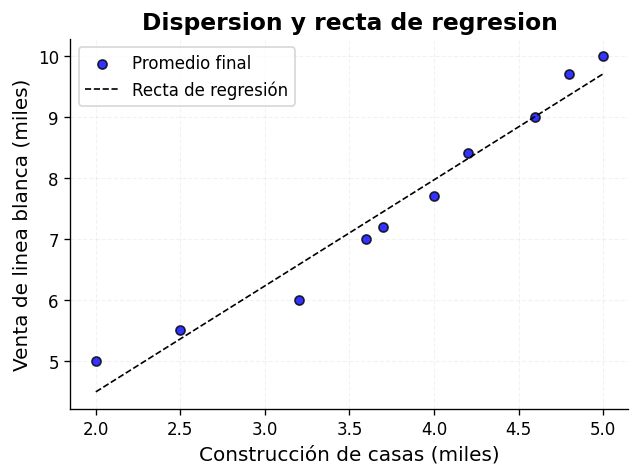

In [128]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersion y recta de regresion',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Venta de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [129]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-0.074848,2.108368
Construcción_de_casas,1.455693,2.019435


# **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.8463507249054649


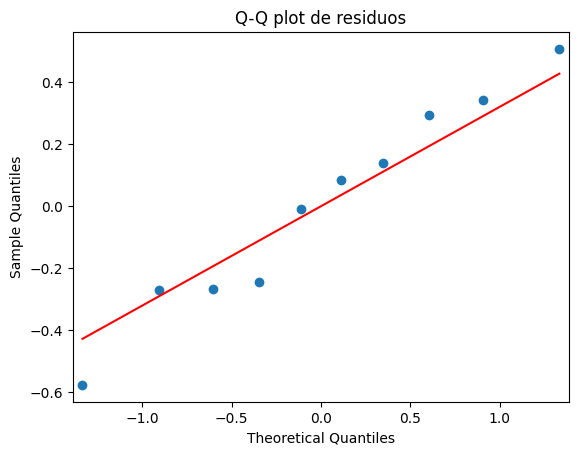

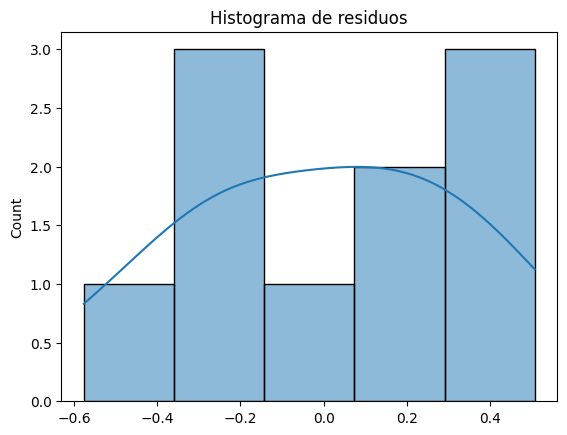

In [130]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**Los errores son repartidos equitativamente según la prueba de shapiro.**

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

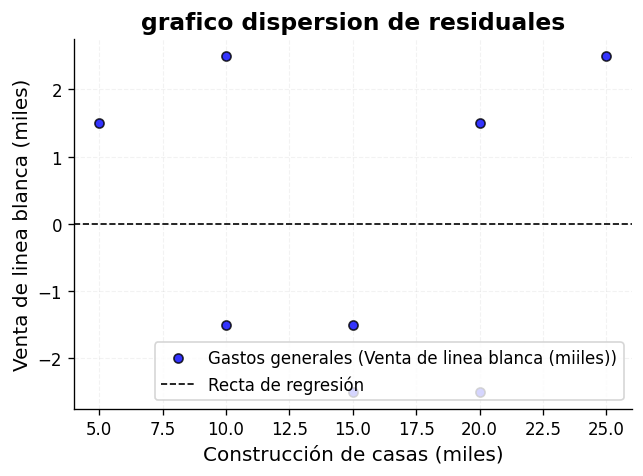

In [154]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales (Venta de linea blanca (miiles))' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'grafico dispersion de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construcción de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Venta de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Como los datos estan dispersos, nos indica que los errorres no se relacionan y que la formuls funciona de manera de manera correcta.**

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [132]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.1581



**La prueba nos confirma que al ser p > 0.05, los errores son parejos por ambas partes, tanto en la venta como en la contrucción.**

# **11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [133]:
modelo.predict([1, 7.5])

array([14.04848907])

In [134]:
modelo.predict([1, 8.2])

array([15.26478382])

In [135]:
modelo.predict([1, 12.0])

array([21.86752673])

**Al extrapolar un dato la diferencia no es tanta, por lo que representa un riesgo para la contriucción de casas.**

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [136]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Venta_de_linea_blanca ~ Construcción_de_casas', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)

**Interpretación:** Podemos confirmar que nuestros argumentos reafirman que la venta de lienas depende de la contrucción de casas.

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [137]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/evelyndenissegonzalez-lang/Estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_05.csv"
df = pd.read_csv(link_csv)
df

,número_interrupciones_al_trabajador,calificación_del_trabajador_en_la_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


# **1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

In [138]:
x = df ['número_interrupciones_al_trabajador']
y = df['calificación_del_trabajador_en_la_prueba_de_hostilidad']

# **2.   Realice un diagrama de dispersión para estos datos.**

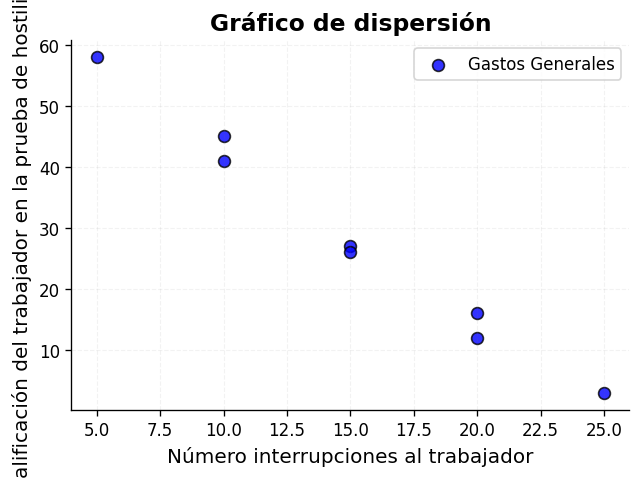

In [139]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos Generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número interrupciones al trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación del trabajador en la prueba de hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )


# **3. ¿Los datos soportan la suposición de linealidad?** Si, ya que los datos se ajustan a este supuesto.

# **4. Calcule el coeficiente de correlación e interprete el resultado.**

In [140]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
Valor p:  0.0000


**Interpretacón:** Los resultados del codigo muestra que hay relación, ya que mientras mas molesten al empleado se vuelve mas hostil.


In [141]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,70.5
número_interrupciones_al_trabajador,-2.8


$$
\hat{y} = 70.5+-2.8x
$$
donde
- $\hat{y}$ Calificación del trabajador en la prueba de hostilidad
- $X$ Número interrupciones al trabajador

# **5. Calcule el coeficiente de determinación e interprete el resultado.**

In [142]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  98.58%



**Este porcetntaje alto indica a la sinterrupciones, mientras que lo restante es diferente.**

**Interpretación:**

# **6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

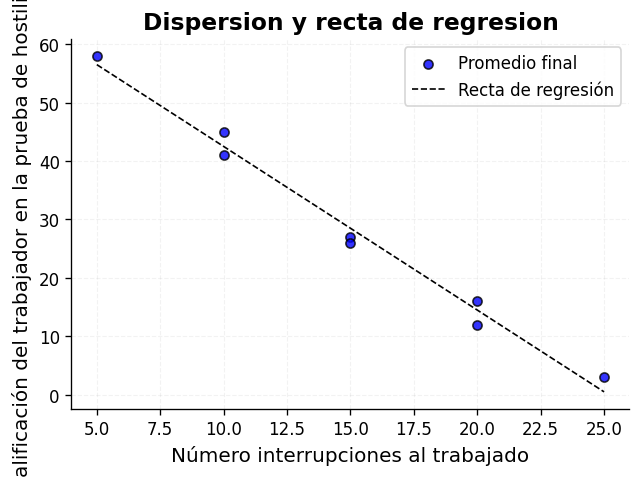

In [143]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Dispersion y recta de regresion',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número interrupciones al trabajado',
    fontsize=12
)

plt.ylabel(
    'Calificación del trabajador en la prueba de hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

# **7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

In [144]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,65.051384,75.948616
número_interrupciones_al_trabajador,-3.136296,-2.463704


## **9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.054816491127669634


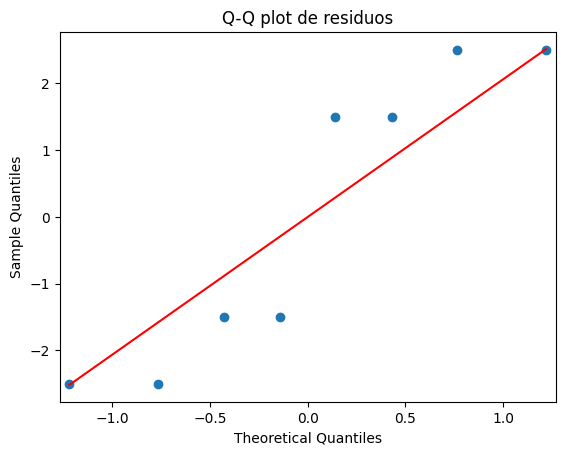

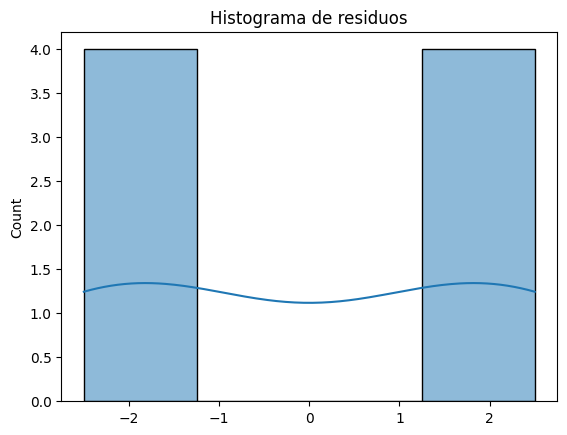

In [145]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

**El valor salio p> 0.05 por muy poco, pero realmente es un indicador para saber que los errores tienen una distribución similar tanto en la actitud como en las interrupciones.**

# **8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

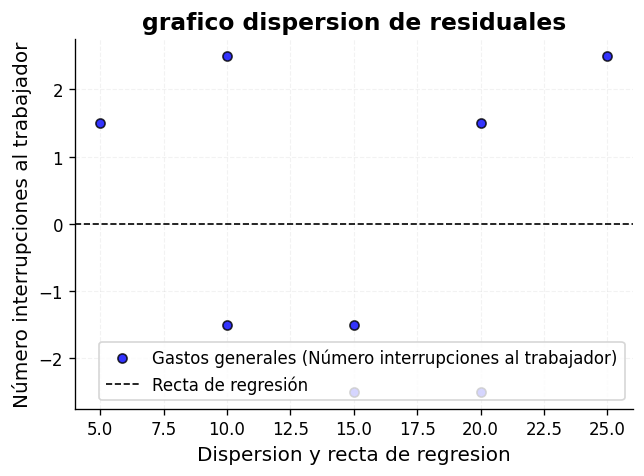

In [155]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos generales (Número interrupciones al trabajador)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'grafico dispersion de residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Dispersion y recta de regresion',
    fontsize=12
)

plt.ylabel(
    'Número interrupciones al trabajador',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

**Los errores al no tener un orden en particular, la formular de manera correcta.**

# **10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [147]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2482



**La prueba funciona bien para medir la hostilidad, ya que al ser > 0.05 dice que los datos son estables y parejos para ambos lugares.**

# **11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [148]:
modelo.predict([1, 12])

array([36.9])

In [149]:
modelo.predict([1, 27])

array([-5.1])

In [150]:
modelo.predict([1, 60])

array([-97.5])

**Si calculamos la hostilidad en un lugar fuera, no sabemos predecir fuera de los gráficos y datos mostrados, por lo que una cantidad ilógica.**

# **12. Realice una tabla ANOVA e interprete el resultado.**

In [151]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('calificación_del_trabajador_en_la_prueba_de_hostilidad~ número_interrupciones_al_trabajador', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)

**Comprobamos que nuestros argumentos y las pruebas son suficientes para decir que las insprecciones son causas de la hostilidad.**